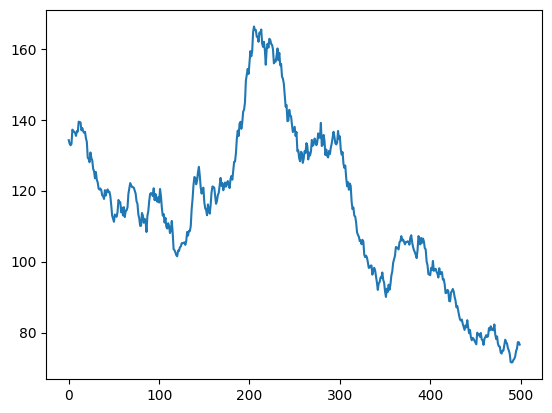

In [31]:
import pandas as pd
import numpy as np

prices = pd.read_csv("prices.txt", sep=r"\s+")
returns = prices.pct_change()
assets = prices.columns

prices.head()
plt.plot(prices["SRNA"])


In [26]:
lookbacks = [5, 10, 20, 30, 40, 50, 60, 70]
starting_horizon_weights = {lookback: 1 / len(lookbacks) for lookback in lookbacks}

# Use information only up to t-1, then create the signal for time t.
past_returns = returns.shift(1)

risk_adjusted_momentum = {}
z_scores = {}

for lookback in lookbacks:
    momentum = past_returns.rolling(lookback).sum()
    volatility = past_returns.rolling(lookback).std()
    vol_normalised = momentum / volatility.replace(0, np.nan)

    cross_sectional_mean = vol_normalised.mean(axis=1)
    cross_sectional_std = vol_normalised.std(axis=1)
    z_score = vol_normalised.sub(cross_sectional_mean, axis=0).div(cross_sectional_std, axis=0)

    risk_adjusted_momentum[lookback] = vol_normalised
    z_scores[lookback] = z_score

def sharpe_ratio(return_series):
    daily_volatility = return_series.std()
    if daily_volatility <= 0 or pd.isna(daily_volatility):
        return np.nan
    return np.sqrt(250) * return_series.mean() / daily_volatility


def make_candidate_weight_sets(lookbacks, grid_step):
    units = int(round(1 / grid_step))
    candidates = []

    def build(index, remaining_units, current_weights):
        if index == len(lookbacks) - 1:
            current_weights[lookbacks[index]] = remaining_units * grid_step
            candidates.append({lookback: round(weight, 10) for lookback, weight in current_weights.items()})
            return

        lookback = lookbacks[index]
        for weight_units in range(remaining_units + 1):
            next_weights = current_weights.copy()
            next_weights[lookback] = weight_units * grid_step
            build(index + 1, remaining_units - weight_units, next_weights)

    build(0, units, {})
    return candidates


grid_step = 0.20
train_end = len(prices) - 250
candidate_weight_sets = make_candidate_weight_sets(lookbacks, grid_step)
print("Number of candidate weight sets:", len(candidate_weight_sets))

asset_weight_rows = []

for asset in assets:
    asset_results = []

    for candidate_weights in candidate_weight_sets:
        candidate_signal = sum(candidate_weights[lookback] * z_scores[lookback][asset] for lookback in lookbacks)
        candidate_returns = (candidate_signal.shift(1) * returns[asset]).dropna()
        train_returns = candidate_returns.iloc[:train_end]
        test_returns = candidate_returns.iloc[train_end:]

        asset_results.append({
            "asset": asset,
            **{f"a{lookback}": candidate_weights[lookback] for lookback in lookbacks},
            "train_sharpe": sharpe_ratio(train_returns),
            "test_sharpe": sharpe_ratio(test_returns),
            "train_total_return": (1 + train_returns).prod() - 1,
            "test_total_return": (1 + test_returns).prod() - 1,
        })

    best_asset_row = pd.DataFrame(asset_results).sort_values("train_sharpe", ascending=False).iloc[0]
    asset_weight_rows.append(best_asset_row)

asset_horizon_weights = pd.DataFrame(asset_weight_rows).set_index("asset")
asset_horizon_weights = asset_horizon_weights.sort_values("train_sharpe", ascending=False)
display(asset_horizon_weights)
print("Starting horizon weights:", starting_horizon_weights)

n_selected_assets = 33
selected_assets = asset_horizon_weights.head(n_selected_assets).index.tolist()
print("Selected assets:", selected_assets)
display(asset_horizon_weights.loc[selected_assets])

signals = pd.DataFrame(0.0, index=returns.index, columns=assets)

for asset in selected_assets:
    asset_weights = asset_horizon_weights.loc[asset]
    signals[asset] = sum(asset_weights[f"a{lookback}"] * z_scores[lookback][asset] for lookback in lookbacks)

# Method A: proportional weights. Positive = long, negative = short.
gross_signal = signals.abs().sum(axis=1)
weights = signals.div(gross_signal.replace(0, np.nan), axis=0).fillna(0)

latest_scores = signals.iloc[-1].sort_values(ascending=False)
latest_weights = weights.iloc[-1].sort_values(ascending=False)

display(latest_scores.head(10).to_frame("score"))
display(latest_scores.tail(10).to_frame("score"))
display(latest_weights[latest_weights.abs() > 0].to_frame("weight"))


Number of candidate weight sets: 792


,a5,a10,a20,a30,a40,a50,a60,a70,train_sharpe,test_sharpe,train_total_return,test_total_return
asset,,,,,,,,,,,,
NPCK,0.6,0.0,0.0,0.4,0.0,0.0,0.0,0.0,2.553687,-0.327011,0.943999,-0.055252
SRNA,0.4,0.0,0.6,0.0,0.0,0.0,0.0,0.0,2.544426,1.025778,0.931728,0.200316
NWIG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.088738,-0.117564,0.886049,-0.069995
OTCS,0.2,0.0,0.0,0.0,0.0,0.8,0.0,0.0,1.905466,-1.391759,1.372023,-0.344606
RCRI,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.733036,-1.174521,1.210037,-0.464412
FARS,0.2,0.0,0.0,0.0,0.8,0.0,0.0,0.0,1.687799,-0.396019,0.496937,-0.069856
HUXZ,0.8,0.2,0.0,0.0,0.0,0.0,0.0,0.0,1.494183,0.705075,0.498092,0.126412
AENO,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.382322,0.379337,0.437287,0.049482
HTRK,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.342964,-2.046563,0.364043,-0.361152


Starting horizon weights: {5: 0.125, 10: 0.125, 20: 0.125, 30: 0.125, 40: 0.125, 50: 0.125, 60: 0.125, 70: 0.125}
Selected assets: ['NPCK', 'SRNA', 'NWIG', 'OTCS', 'RCRI', 'FARS', 'HUXZ', 'AENO', 'HTRK', 'DUCT', 'ILVX', 'MMBT', 'HETT', 'HRND', 'IHOZ', 'ELLT', 'ANSO', 'HRET', 'ACAC', 'MDGI', 'RRES', 'MSDP', 'CUBO', 'SMAH', 'DIHO', 'BLBT', 'MTNS', 'LSST', 'ACIX', 'ITPA', 'EORC', 'ALUT', 'EAFC']


,a5,a10,a20,a30,a40,a50,a60,a70,train_sharpe,test_sharpe,train_total_return,test_total_return
asset,,,,,,,,,,,,
NPCK,0.6,0.0,0.0,0.4,0.0,0.0,0.0,0.0,2.553687,-0.327011,0.943999,-0.055252
SRNA,0.4,0.0,0.6,0.0,0.0,0.0,0.0,0.0,2.544426,1.025778,0.931728,0.200316
NWIG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.088738,-0.117564,0.886049,-0.069995
OTCS,0.2,0.0,0.0,0.0,0.0,0.8,0.0,0.0,1.905466,-1.391759,1.372023,-0.344606
RCRI,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.733036,-1.174521,1.210037,-0.464412
FARS,0.2,0.0,0.0,0.0,0.8,0.0,0.0,0.0,1.687799,-0.396019,0.496937,-0.069856
HUXZ,0.8,0.2,0.0,0.0,0.0,0.0,0.0,0.0,1.494183,0.705075,0.498092,0.126412
AENO,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.382322,0.379337,0.437287,0.049482
HTRK,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.342964,-2.046563,0.364043,-0.361152


,score
MTNS,3.188097
HRET,2.523520
OTCS,1.692895
IHOZ,1.528655
CUBO,0.684688
SRNA,0.668241
DIHO,0.635154
BLBT,0.537767
FARS,0.526030
ACAC,0.499665


,score
MMBT,-0.412573
NPCK,-0.464734
MDGI,-0.501129
EORC,-0.717464
RCRI,-0.744462
ANSO,-0.790627
ILVX,-1.013546
EAFC,-1.268604
MSDP,-1.432788
RRES,-2.199904


,weight
MTNS,0.123305
HRET,0.097601
OTCS,0.065475
IHOZ,0.059123
CUBO,0.026481
SRNA,0.025845
DIHO,0.024566
BLBT,0.020799
FARS,0.020345
ACAC,0.019325


,train,test,all
mean_daily_return,0.001257,0.000175,0.000716
daily_volatility,0.004205,0.004762,0.004520
annualised_sharpe,4.728223,0.580383,2.505015
total_return,0.366122,0.041720,0.423116


<Axes: title={'center': 'Multi-horizon relative momentum cumulative return'}>

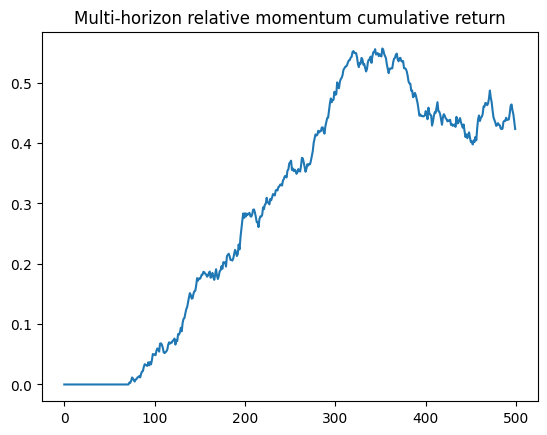

In [27]:
# Simple sanity-check backtest: positions from t-1 earn returns at t.
strategy_returns = (weights.shift(1) * returns).sum(axis=1).dropna()
train_strategy_returns = strategy_returns.iloc[:train_end]
test_strategy_returns = strategy_returns.iloc[train_end:]
cumulative_returns = (1 + strategy_returns).cumprod() - 1

def performance_summary(return_series):
    daily_volatility = return_series.std()
    annualised_sharpe = np.nan
    if daily_volatility > 0:
        annualised_sharpe = np.sqrt(250) * return_series.mean() / daily_volatility

    return pd.Series({
        "mean_daily_return": return_series.mean(),
        "daily_volatility": daily_volatility,
        "annualised_sharpe": annualised_sharpe,
        "total_return": (1 + return_series).prod() - 1,
    })

summary = pd.DataFrame({
    "train": performance_summary(train_strategy_returns),
    "test": performance_summary(test_strategy_returns),
    "all": performance_summary(strategy_returns),
})

display(summary)
cumulative_returns.plot(title="Multi-horizon relative momentum cumulative return")


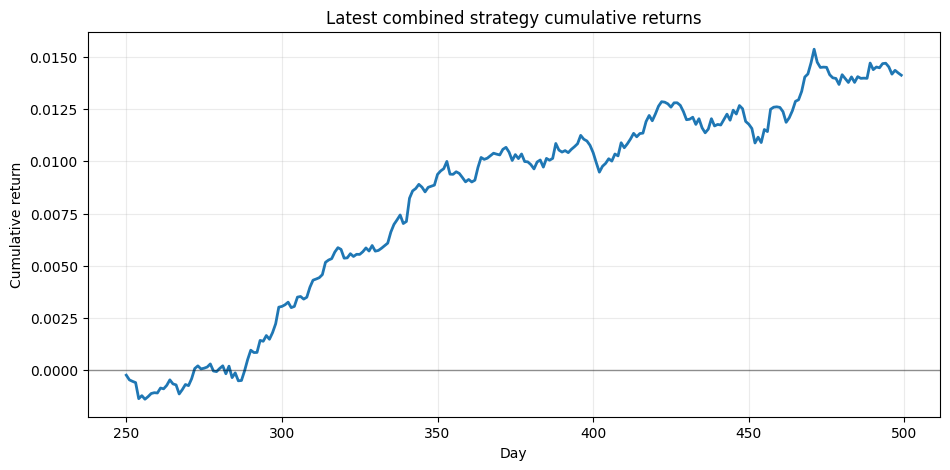

Final cumulative return: 1.41%
Annualised Sharpe: 2.995


In [29]:
# Cumulative returns for the latest combined strategy in teamName.py
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import teamName
importlib.reload(teamName)

prices_df = pd.read_csv("prices.txt", sep=r"\s+")
prices_array = prices_df.values.T
n_assets, n_days = prices_array.shape
num_test_days = 250
start_day = n_days - num_test_days

commission_rate = np.full(n_assets, 0.0001)
commission_rate[0] = 0.00002
position_limit_dollars = np.full(n_assets, 10_000)
position_limit_dollars[0] = 100_000

cash = 0.0
current_position = np.zeros(n_assets)
portfolio_value = 0.0
daily_pl = []
portfolio_values = []

for t in range(start_day, n_days + 1):
    price_history = prices_array[:, :t]
    current_prices = price_history[:, -1]

    if t < n_days:
        desired_position = teamName.getMyPosition(price_history)
        position_limits = (position_limit_dollars / current_prices).astype(int)
        new_position = np.clip(desired_position, -position_limits, position_limits).astype(int)
    else:
        new_position = current_position.copy()

    trade = new_position - current_position
    traded_dollars = current_prices * np.abs(trade)
    commission = np.sum(traded_dollars * commission_rate)
    cash -= current_prices.dot(trade) + commission

    current_position = new_position
    new_portfolio_value = cash + current_position.dot(current_prices)

    if t > start_day:
        daily_pl.append(new_portfolio_value - portfolio_value)
        portfolio_values.append(new_portfolio_value)

    portfolio_value = new_portfolio_value

daily_pl = pd.Series(daily_pl, index=prices_df.index[start_day:], name="daily_pl")
notional = teamName.GROSS_DOLLAR_EXPOSURE
strategy_returns = daily_pl / notional
cumulative_returns = (1 + strategy_returns).cumprod() - 1

fig, ax = plt.subplots(figsize=(11, 5))
cumulative_returns.plot(ax=ax, linewidth=2)
ax.axhline(0, color="black", linewidth=1, alpha=0.4)
ax.set_title("Latest combined strategy cumulative returns")
ax.set_xlabel("Day")
ax.set_ylabel("Cumulative return")
ax.grid(True, alpha=0.25)
plt.show()

print(f"Final cumulative return: {cumulative_returns.iloc[-1]:.2%}")
print(f"Annualised Sharpe: {np.sqrt(250) * strategy_returns.mean() / strategy_returns.std():.3f}")
